# Project 1 — Ridge Regression
## Employee Salary Prediction (multicollinear features)

Predicting salary from years of experience, education level, number of certifications, age, and projects completed — several of these are naturally correlated with each other, a good showcase for Ridge.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 700
experience = np.random.uniform(0, 30, n)
age = experience + np.random.normal(24, 3, n)   # age correlated with experience
education_level = np.random.randint(1, 6, n)     # 1=highschool ... 5=phd
certifications = (experience/5 + np.random.normal(0,1,n)).clip(0, None).round()  # correlated with experience
projects_completed = (experience*1.5 + np.random.normal(0,3,n)).clip(0, None)    # correlated with experience

salary = (30000 + 1800*experience + 4000*education_level + 900*certifications
          + 200*projects_completed + 100*age + np.random.normal(0, 8000, n))

df = pd.DataFrame({'experience': experience, 'age': age, 'education_level': education_level,
                    'certifications': certifications, 'projects_completed': projects_completed, 'salary': salary})
df.head()


,experience,age,education_level,certifications,projects_completed,salary
0,11.236204,33.280695,2,3.0,18.069048,70311.960361
1,28.521429,52.663625,3,6.0,42.655137,99634.668365
2,21.959818,43.378578,5,3.0,33.279016,107216.622386
3,17.959755,40.806088,2,3.0,24.121652,79687.883827
4,4.680559,31.699438,3,1.0,7.152464,58628.912855


## 2. Preprocessing

In [3]:
X = df.drop('salary', axis=1)
y = df['salary']
print("Correlation matrix:")
print(X.corr().round(2))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Correlation matrix:
                    experience   age  education_level  certifications  \
experience                1.00  0.95             0.02            0.87   
age                       0.95  1.00             0.03            0.82   
education_level           0.02  0.03             1.00            0.00   
certifications            0.87  0.82             0.00            1.00   
projects_completed        0.98  0.93             0.02            0.84   

                    projects_completed  
experience                        0.98  
age                               0.93  
education_level                   0.02  
certifications                    0.84  
projects_completed                1.00  


## 3. Train Model

In [4]:
from sklearn.linear_model import Ridge, RidgeCV

# find best alpha via cross-validation
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1, 10, 50, 100], cv=5)
ridge_cv.fit(X_train_scaled, y_train)
print("Best alpha:", ridge_cv.alpha_)

model = Ridge(alpha=ridge_cv.alpha_)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


Best alpha: 1.0


## 4. Evaluate

In [5]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 6261.784271838517
RMSE: 7611.778861673211
R2 Score: 0.8906428710686317


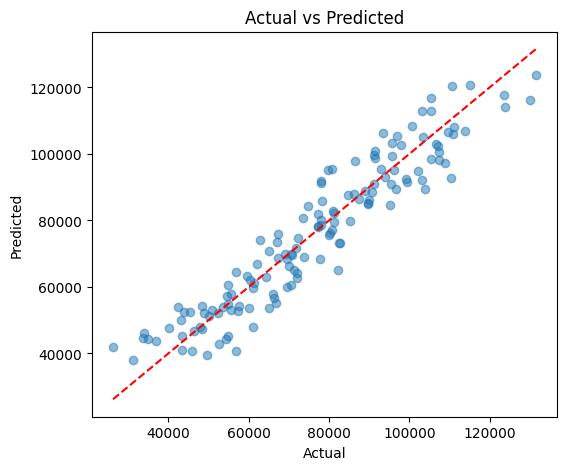

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Actual vs Predicted')
plt.show()


## Takeaways
- Notice the correlation matrix — experience, age, certifications, and projects_completed are all correlated. Plain Linear Regression would give unstable coefficients here; Ridge spreads the weight more sensibly.
- Compare `Ridge` coefficients against a plain `LinearRegression` fit on the same data to see the shrinkage effect directly.
- Next steps: try very high alpha (e.g., 1000) and watch all coefficients shrink toward zero — the model becomes closer to just predicting the mean.

---
# Project 2 — Your Turn
**Dataset:** Linnerud dataset (`sklearn.datasets.load_linnerud`) — predict physiological measurements from exercise data (small, classic multicollinear-ish dataset).

```python
from sklearn.datasets import load_linnerud
data = load_linnerud()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.DataFrame(data.target, columns=data.target_names)['Weight']  # pick one target
```
**Tasks:** scale features, use `RidgeCV` to find the best alpha, train Ridge, evaluate with MAE/RMSE/R², and compare coefficients against plain Linear Regression.
